# 03 — Figure generation

This notebook builds a **multi-model comparison figure** from REF metric values
and saves it in formats suitable for a paper or report.

**Prerequisites:** [01 — REF concepts](01-ref-concepts.ipynb), [02 — Querying the REF API](02-querying-the-api.ipynb).

**What you need:** an internet connection.

## Goal

We want a single figure that compares many CMIP models on one scalar diagnostic — the
kind of figure you would put in a paper. We will:

1. fetch scalar metric values for a diagnostic;
2. tidy them into a `DataFrame`;
3. apply a consistent publication plotting style;
4. build and save the figure.

In [1]:
from ref_tutorials import (
    get_client,
    metric_values_to_dataframe,
    model_comparison_figure,
    save_figure,
    set_publication_style,
)

client = get_client()
set_publication_style()

## 1–2. Fetch and tidy the metric values

We pick a diagnostic that exposes scalar values and load them into a tidy frame.

In [2]:
from climate_ref_client.api.diagnostics import (
    diagnostics_list,
    diagnostics_list_metric_values,
)
from climate_ref_client.models.metric_value_type import MetricValueType

provider_slug = "esmvaltool"
diagnostic_slug = "equilibrium-climate-sensitivity"

values = diagnostics_list_metric_values.sync(
    provider_slug=provider_slug,
    diagnostic_slug= diagnostic_slug,
    value_type=MetricValueType.SCALAR,
    client=client,
).data

df = metric_values_to_dataframe(values)
df.head()

,source_id,grid_label,member_id,metric,region,value
0,ACCESS-CM2,gn,r1i1p1f1,ecs,global,4.719077
1,BCC-CSM2-MR,gn,r1i1p1f1,ecs,global,3.041841
2,BCC-ESM1,gn,r1i1p1f1,ecs,global,3.258833
3,CAS-ESM2-0,gn,r1i1p1f1,ecs,global,3.523785
4,CNRM-CM6-1,gr,r1i1p1f2,ecs,global,4.829452


A diagnostic often reports several *statistics*. For a clean comparison figure we focus
on one statistic, and on the metric values that carry a `source_id` (the model name).

In [3]:
df

,source_id,grid_label,member_id,metric,region,value
0,ACCESS-CM2,gn,r1i1p1f1,ecs,global,4.719077
1,BCC-CSM2-MR,gn,r1i1p1f1,ecs,global,3.041841
2,BCC-ESM1,gn,r1i1p1f1,ecs,global,3.258833
3,CAS-ESM2-0,gn,r1i1p1f1,ecs,global,3.523785
4,CNRM-CM6-1,gr,r1i1p1f2,ecs,global,4.829452
5,CNRM-ESM2-1,gr,r1i1p1f2,ecs,global,4.764173
6,CNRM-ESM2-1,gr,r3i1p1f2,ecs,global,4.761467
7,IPSL-CM5A2-INCA,gr,r1i1p1f1,ecs,global,3.800174
8,MRI-ESM2-0,gn,r10i1p1f1,ecs,global,3.522943
9,MRI-ESM2-0,gn,r13i1p1f1,ecs,global,3.626053


In [4]:
subset = df.dropna(subset=["source_id", "value"]).copy()
statistic = subset["metric"].unique()[0]

print(f"Statistic: {statistic}")
print(f"Models:    {subset['source_id'].nunique()}")
subset.head()

Statistic: ecs
Models:    25


,source_id,grid_label,member_id,metric,region,value
0,ACCESS-CM2,gn,r1i1p1f1,ecs,global,4.719077
1,BCC-CSM2-MR,gn,r1i1p1f1,ecs,global,3.041841
2,BCC-ESM1,gn,r1i1p1f1,ecs,global,3.258833
3,CAS-ESM2-0,gn,r1i1p1f1,ecs,global,3.523785
4,CNRM-CM6-1,gr,r1i1p1f2,ecs,global,4.829452


## 3–4. Build the figure

`model_comparison_figure` draws one bar per model, sorted by value. Where a model has
several ensemble members it is aggregated to its mean and the spread is shown as an
error bar. The figure already uses the publication style we applied above.

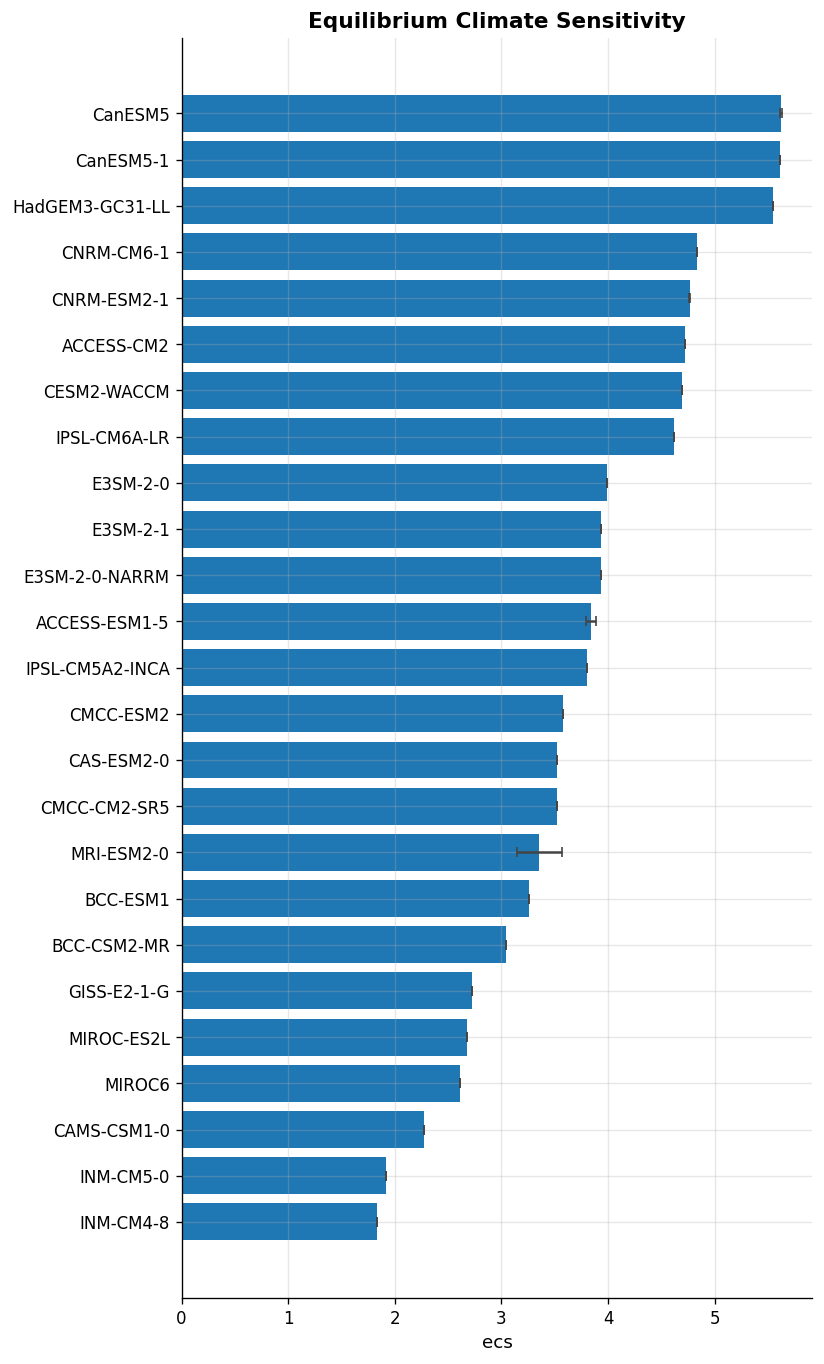

In [5]:
fig, ax = model_comparison_figure(
    subset,
    value_col="value",
    model_col="source_id",
    title=f"Equilibrium Climate Sensitivity",
    ylabel=str(statistic),
)

The returned `fig` and `ax` are ordinary matplotlib objects, so you can keep tweaking —
add a reference line, annotate, change colours — before saving.

## Save the figure

`save_figure` writes both a `.png` (quick viewing) and a `.pdf` (vector, for papers)
at 300 dpi.

In [6]:
written = save_figure(fig, "output/model-comparison")
written

[PosixPath('output/model-comparison.png'),
 PosixPath('output/model-comparison.pdf')]

## Adapting this recipe

To make the same figure for a different diagnostic, change the `diagnostic` selection in
step 1. To compare a different quantity, change `statistic`. The helper functions
(`metric_values_to_dataframe`, `model_comparison_figure`, `save_figure`) stay the same —
see `src/ref_tutorials/` if you want to see how they work or extend them.

**Next:** [04 — Running a diagnostic locally](04-local-diagnostic-run.ipynb).